<a href="https://colab.research.google.com/github/Gotte-sahithi/ML-Skill/blob/main/WEEK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files

In [20]:
sns.set_style("whitegrid")

In [21]:
# Load Titanic dataset
df = pd.read_csv('Titanic-Dataset.csv')


In [22]:
# Display first 5 rows
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [23]:
# Display dataset information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [24]:
# Missingness Heatmap
fig1 = plt.figure(figsize=(10, 6))


<Figure size 1000x600 with 0 Axes>

<Axes: >

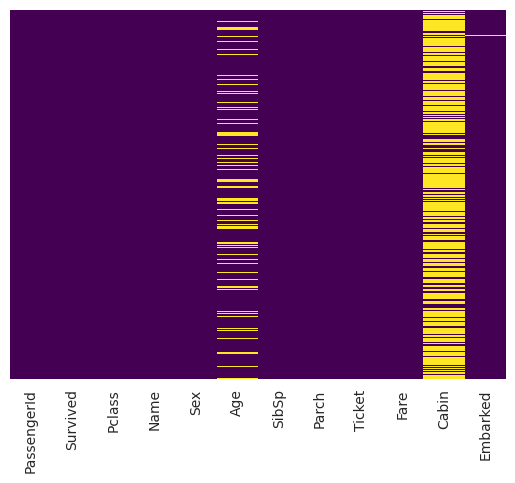

In [25]:
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis",
    yticklabels=False
)


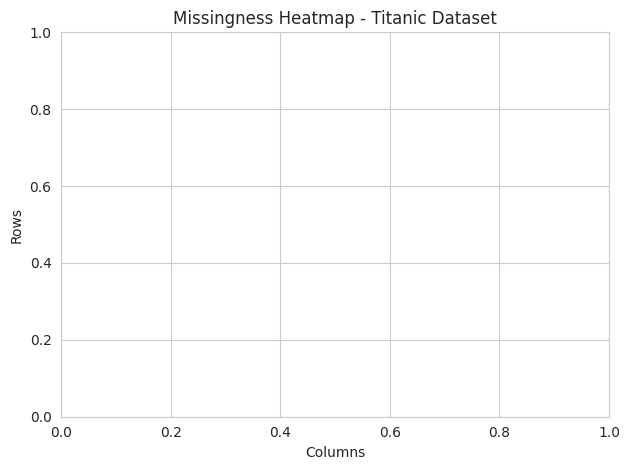

In [26]:
plt.title("Missingness Heatmap - Titanic Dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

In [27]:
num_cols = [
    'Survived',
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare'
]

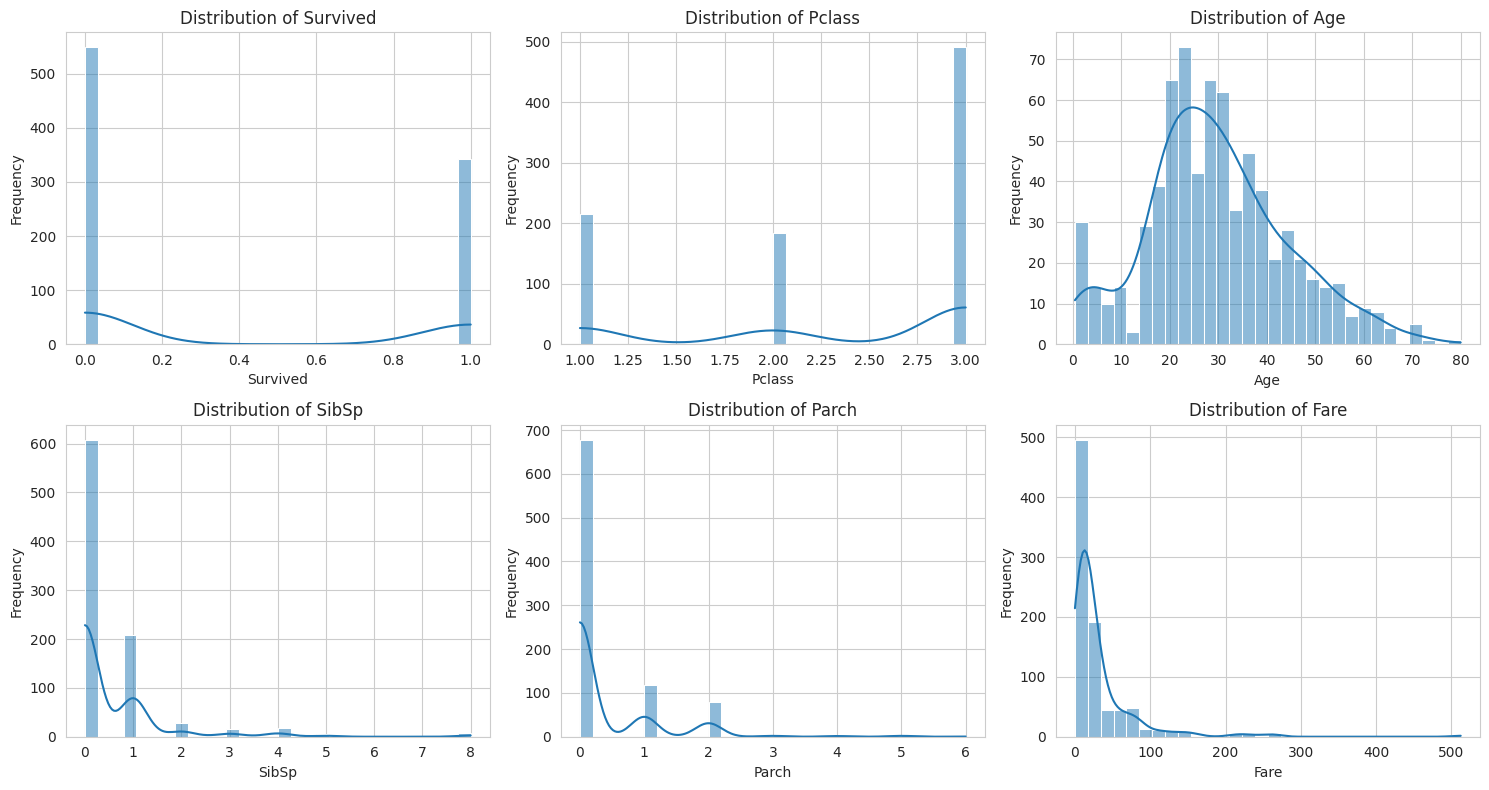

In [28]:
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if col in df.columns:
        sns.histplot(
            df[col].dropna(),
            bins=30,
            kde=True,
            ax=axes[i]
        )
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [29]:
pdf = PdfPages('Titanic_EDA_Report.pdf')

# Page 1: Missingness Heatmap
pdf.savefig(fig1)

# Page 2: Six Histograms
pdf.savefig(fig2)

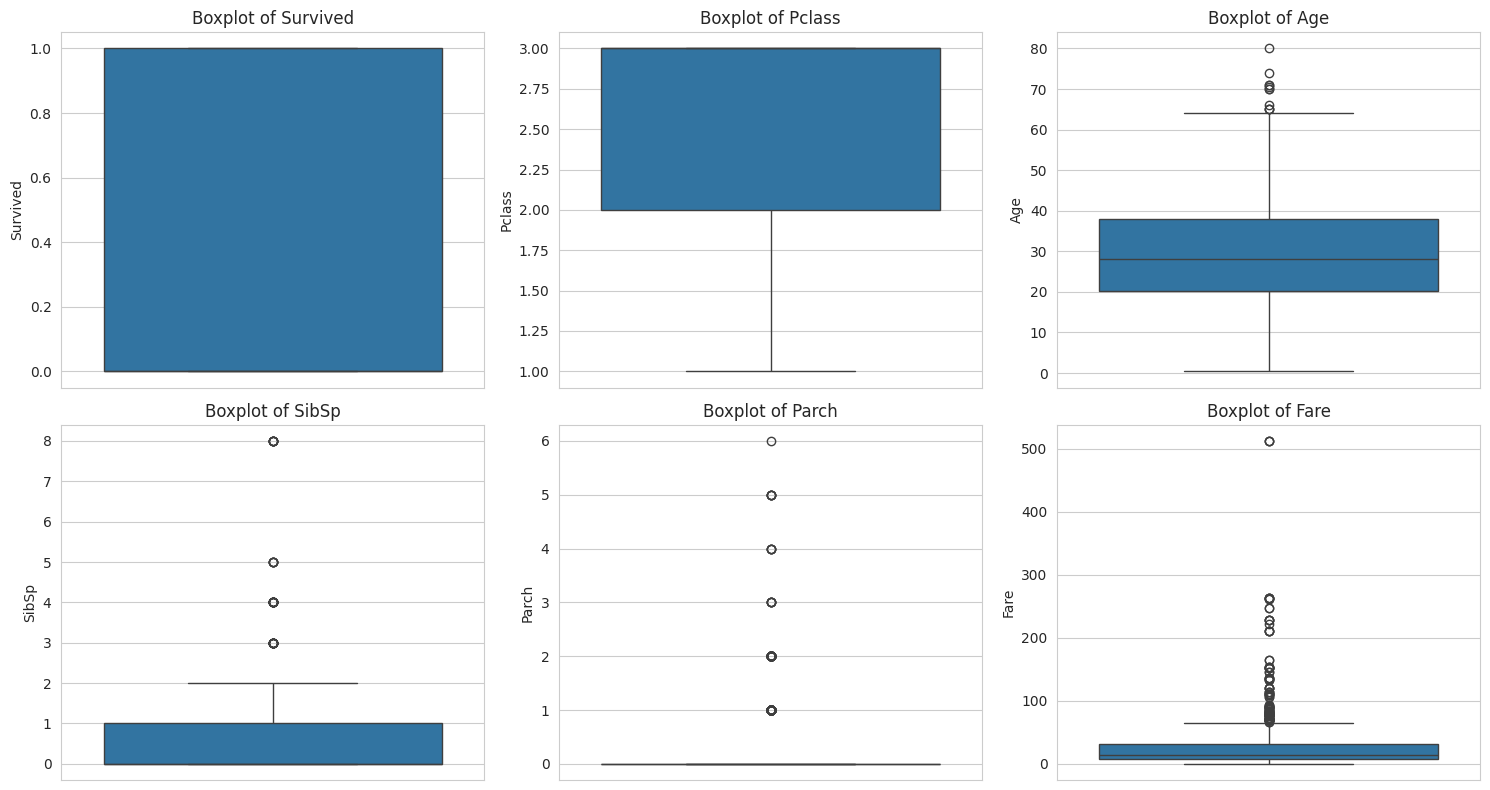

In [30]:
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))
axes5 = axes5.flatten()

for i, col in enumerate(num_cols):
    if col in df.columns:
        sns.boxplot(
            y=df[col],
            ax=axes5[i]
        )
        axes5[i].set_title(f'Boxplot of {col}')
        axes5[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Page 3: Boxplots
pdf.savefig(fig5)

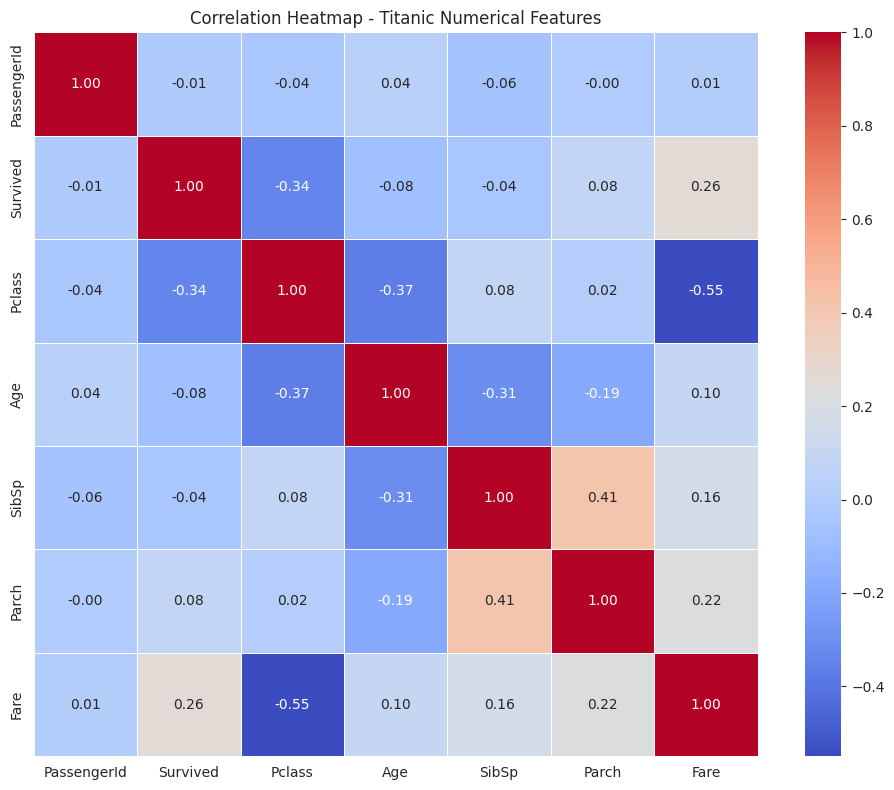

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(
    include=['int64', 'float64']
)

corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap - Titanic Numerical Features')
plt.tight_layout()
plt.show()

# Page 4: Correlation Heatmap
pdf.savefig(fig4)


# Close PDF
pdf.close()

# Download PDF
files.download('Titanic_EDA_Report.pdf')